![](image.png)

# Problem statement

### PDE ###

$$\frac{\partial y}{\partial t} -e^{t}=0$$

### Domain ###

$$t\in[0,2]$$
$$y\in[0,e^{2}]$$

This has the following exact solution:
$$
y(t) = e^{t}
$$

## Workflow overview

>First, we will train a standard neural network to interpolate a small part of the solution, using some observed training points from the solution.

>Next, we will train a PINN to extrapolate the full solution outside of these training points by penalising the underlying differential equation in its loss function. Consider the role of physics in the training process.

In [ ]:
pip install torch torchvision torchaudio

In [ ]:
pip install tensorflow

In [ ]:
!python -m pip install pyDOE --user

In [7]:
from PIL import Image
import numpy as np
import torch
import torch.nn as nn
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import matplotlib.pyplot as plt
import torch
        #Latin Hypercube Sampling
from sklearn.preprocessing import MinMaxScaler

In [9]:
def save_gif_PIL(outfile, files, fps=5, loop=0):
    "Helper function for saving GIFs"
    imgs = [Image.open(file) for file in files]
    imgs[0].save(fp=outfile, format='GIF', append_images=imgs[1:], save_all=True, duration=int(1000/fps), loop=loop)

def physics(x):
    """Defines the analytical solution to the problem.
    """
    y  = torch.exp(x)
    return y

class FCN(nn.Module):
    "Defines a connected network"

    def __init__(self, n_input, n_output, n_hidden, n_layers):
        super().__init__()
        activation = nn.Tanh
        self.fcs = nn.Sequential(*[
                        nn.Linear(n_input, n_hidden),
                        activation()])
        self.fch = nn.Sequential(*[
                        nn.Sequential(*[
                            nn.Linear(n_hidden, n_hidden),
                            activation()]) for _ in range(n_layers-1)])
        self.fce = nn.Linear(n_hidden, n_output)

    def forward(self, x):
        x = self.fcs(x)
        x = self.fch(x)
        x = self.fce(x)
        return x

## Generate training data

> First, we generate some training data from a small part of the true analytical solution.

For this problem, we try to learn the solution over the domain $t\in [0,2]$.

torch.Size([100, 1]) torch.Size([100, 1])
torch.Size([3, 1]) torch.Size([3, 1])


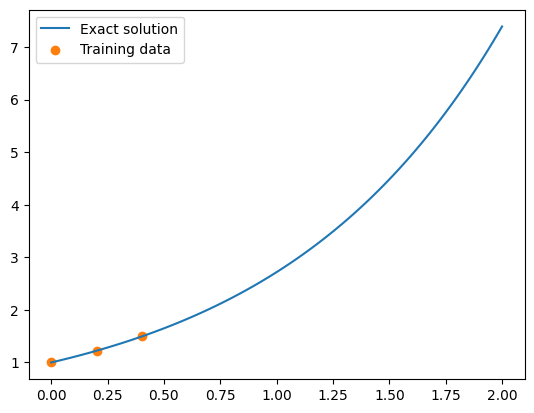

In [ ]:
# get the analytical solution over the full domain
x = torch.linspace(0,2,100).view(-1,1)
y = physics(x).view(-1,1)
print(x.shape, y.shape)

# slice out a small number of points from the LHS of the domain
x_data = x[0:30:10]
y_data = y[0:30:10]
print(x_data.shape, y_data.shape)

plt.figure()
plt.plot(x, y, label="Exact solution")
plt.scatter(x_data, y_data, color="tab:orange", label="Training data")
plt.legend()
plt.show()

## 1. Conventional neural network

> Next, we train a standard neural network (fully connected network) to fit these training points.

>We find that the network is able to fit the solution very closely in the vicinity of the training points, but does not learn an accurate solution outside of them.

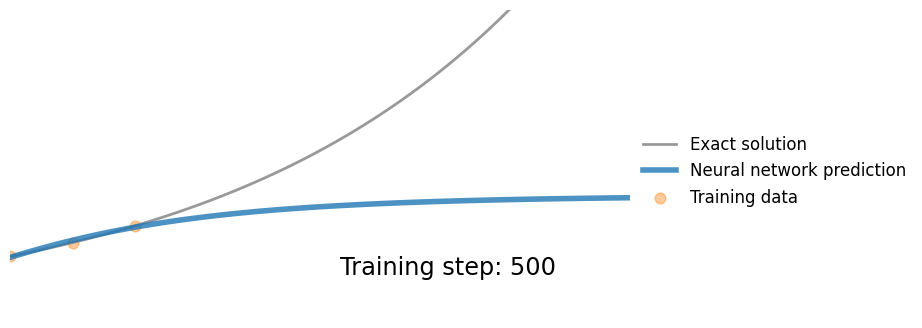

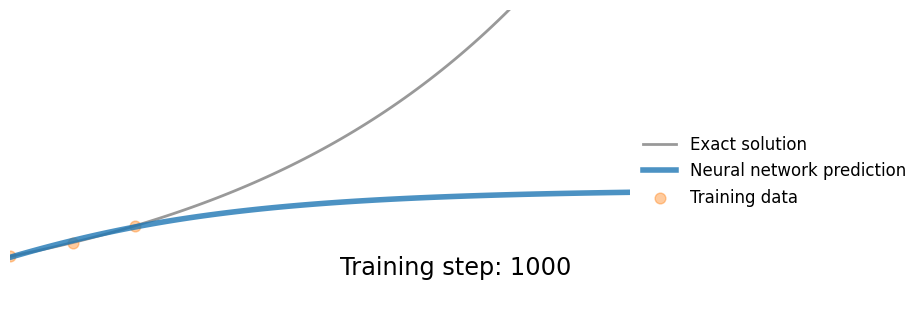

In [ ]:
def plot_result(x,y,x_data,y_data,yh,xp=None):
    "Pretty plot training results"
    plt.figure(figsize=(8,4))
    plt.plot(x,y, color="grey", linewidth=2, alpha=0.8, label="Exact solution")
    plt.plot(x,yh, color="tab:blue", linewidth=4, alpha=0.8, label="Neural network prediction")
    plt.scatter(x_data, y_data, s=60, color="tab:orange", alpha=0.4, label='Training data')
    if xp is not None:
        plt.scatter(xp, -0*torch.ones_like(xp), s=60, color="tab:green", alpha=0.4,
                    label='Physics loss training locations')
    l = plt.legend(loc=(1.01,0.34), frameon=False, fontsize="large")
    plt.setp(l.get_texts(), color="k")
    plt.xlim(0, 2)
    plt.ylim(0, 5)
    plt.text(1.065,0.7,"Training step: %i"%(i+1),fontsize="xx-large",color="k")
    plt.axis("off")


# train standard neural network to fit training data
torch.manual_seed(123)
model = FCN(1,1,30,3)
optimizer = torch.optim.Adam(model.parameters(),lr=1e-3)
files = []
for i in range(1000):
    optimizer.zero_grad()
    yh = model(x_data)
    loss = torch.mean((yh-y_data)**2)# use mean squared error
    loss.backward()
    optimizer.step()


    # plot the result as training progresses
    if (i+1) % 10 == 0:

        yh = model(x).detach()

        plot_result(x,y,x_data,y_data,yh)

        file = "plots/nn_%.8i.png"%(i+1)
        # plt.savefig(file, bbox_inches='tight', pad_inches=0.1, dpi=100, facecolor="white")
        # files.append(file)

        if (i+1) % 500 == 0: plt.show()
        else: plt.close("all")

# save_gif_PIL("nn.gif", files, fps=20, loop=0)

## 2. Physics-informed neural network method (PINN)

> Finally, we add the underlying differential equation ("physics loss") to the loss function.

The physics loss aims to ensure that the learned solution is consistent with the underlying differential equation. This is done by penalising the residual of the differential equation over a set of locations sampled from the domain.

Here we evaluate the physics loss at 30 points uniformly spaced over the problem domain $([0,2])$. We can calculate the derivatives of the network solution with respect to its input variable at these points using `pytorch`'s autodifferentiation features, and can then easily compute the residual of the differential equation using these quantities.

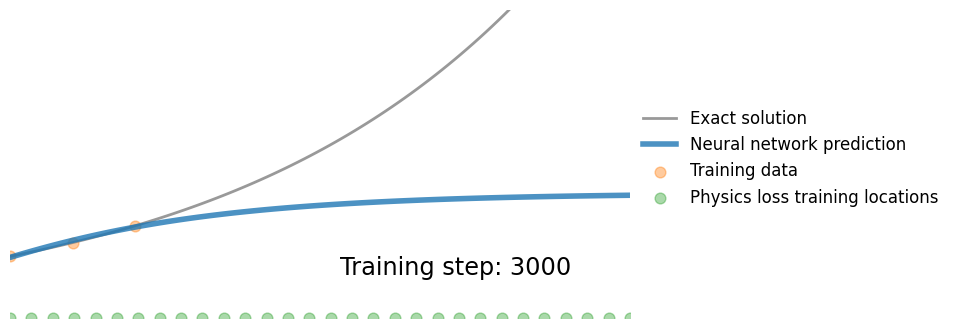

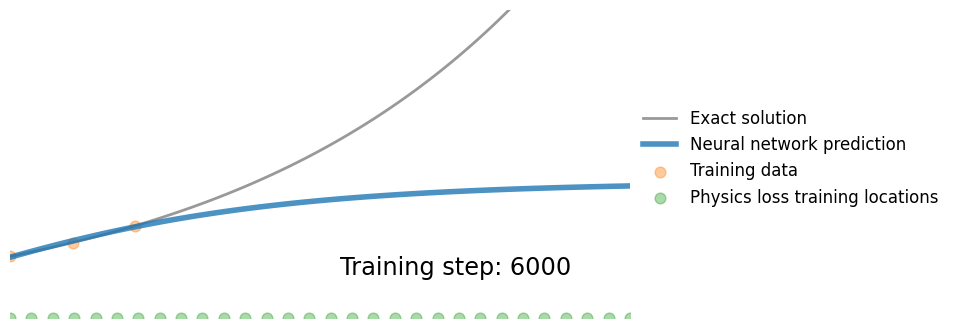

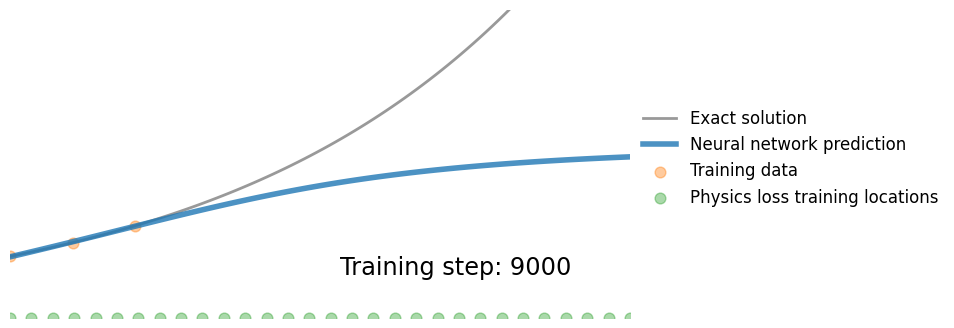

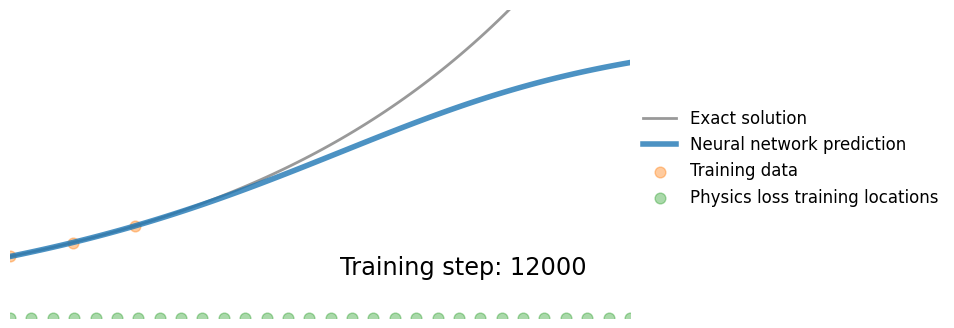

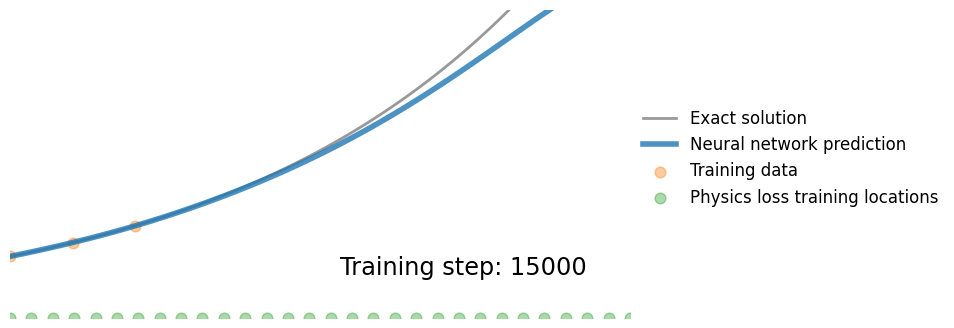

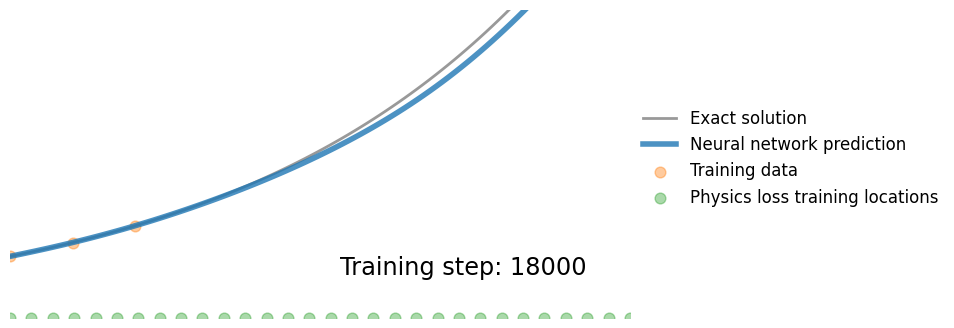

In [ ]:
x_physics = torch.linspace(0,2,30).view(-1,1).requires_grad_(True)# sample locations over the problem domain

torch.manual_seed(123)
model = FCN(1,1,30,3)
optimizer = torch.optim.Adam(model.parameters(),lr=1e-4)
files = []
for i in range(20000):
    optimizer.zero_grad()

    # compute the "data loss"
    yh = model(x_data)
    loss1 = torch.mean((yh-y_data)**2)# use mean squared error

    # compute the "physics loss"
    yhp = model(x_physics)
    dx  = torch.autograd.grad(yhp, x_physics, torch.ones_like(yhp), create_graph=True)[0]# computes dy/dx
    #dx2 = torch.autograd.grad(dx,  x_physics, torch.ones_like(dx),  create_graph=True)[0]# computes d^2y/dx^2
    physics = dx - torch.exp(x_physics)# computes the residual of the 1D differential equation

    loss2 = (1e-4)*torch.mean(physics**2)

    # backpropagate joint loss
    loss = loss1 + loss2# add two loss terms together
    loss.backward()
    optimizer.step()


    # plot the result as training progresses
    if (i+1) % 150 == 0:

        yh = model(x).detach()
        xp = x_physics.detach()

        plot_result(x,y,x_data,y_data,yh,xp)

        file = "plots/pinn_%.8i.png"%(i+1)
        # plt.savefig(file, bbox_inches='tight', pad_inches=0.1, dpi=100, facecolor="white")
        # files.append(file)

        if (i+1) % 3000 == 0: plt.show()
        else: plt.close("all")

# save_gif_PIL("pinn.gif", files, fps=20, loop=0)

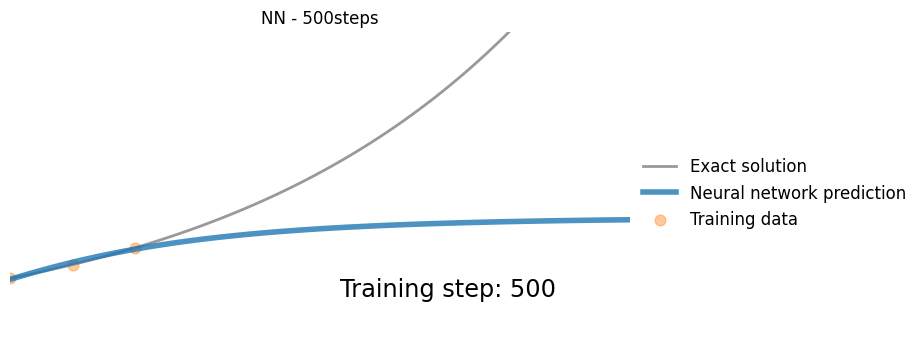

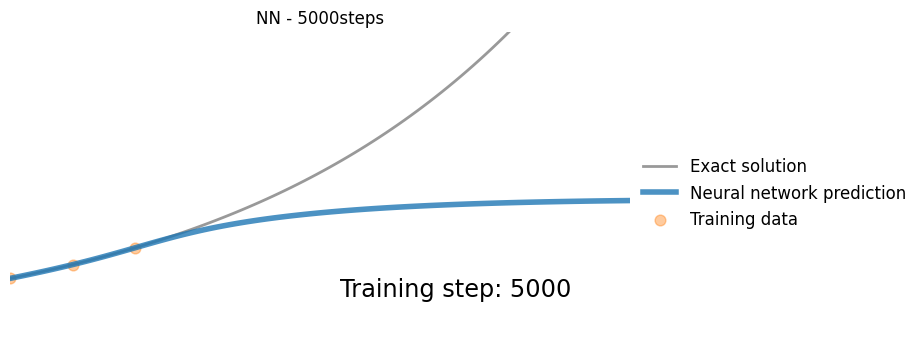

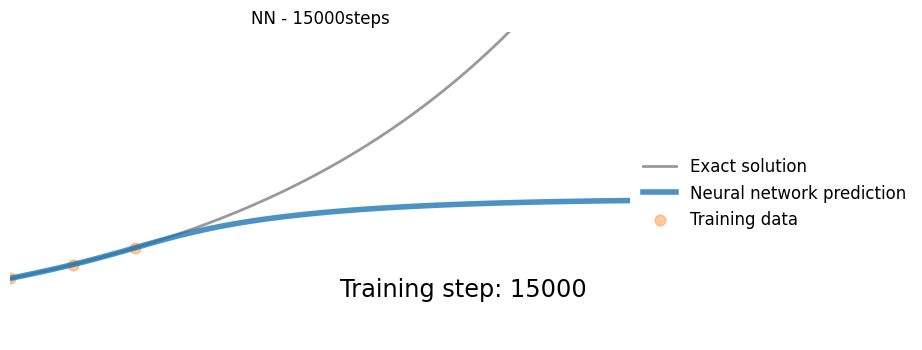

In [ ]:
# ========== Experiment1：Training Steps - NN ==========

# --- 500 Iterations ---
torch.manual_seed(123)
model_nn_500 = FCN(1,1,30,3)
optimizer = torch.optim.Adam(model_nn_500.parameters(),lr=1e-3)
for i in range(500):
    optimizer.zero_grad()
    yh = model_nn_500(x_data)
    loss = torch.mean((yh-y_data)**2)
    loss.backward()
    optimizer.step()
yh = model_nn_500(x).detach()
plot_result(x,y,x_data,y_data,yh)
plt.title("NN - 500steps")
plt.show()

# --- 5000 Iterations ---
torch.manual_seed(123)
model_nn_5000 = FCN(1,1,30,3)
optimizer = torch.optim.Adam(model_nn_5000.parameters(),lr=1e-3)
for i in range(5000):
    optimizer.zero_grad()
    yh = model_nn_5000(x_data)
    loss = torch.mean((yh-y_data)**2)
    loss.backward()
    optimizer.step()
yh = model_nn_5000(x).detach()
plot_result(x,y,x_data,y_data,yh)
plt.title("NN - 5000steps")
plt.show()

# --- 15000 Iterations ---
torch.manual_seed(123)
model_nn_15000 = FCN(1,1,30,3)
optimizer = torch.optim.Adam(model_nn_15000.parameters(),lr=1e-3)
for i in range(15000):
    optimizer.zero_grad()
    yh = model_nn_15000(x_data)
    loss = torch.mean((yh-y_data)**2)
    loss.backward()
    optimizer.step()
yh = model_nn_15000(x).detach()
plot_result(x,y,x_data,y_data,yh)
plt.title("NN - 15000steps")
plt.show()

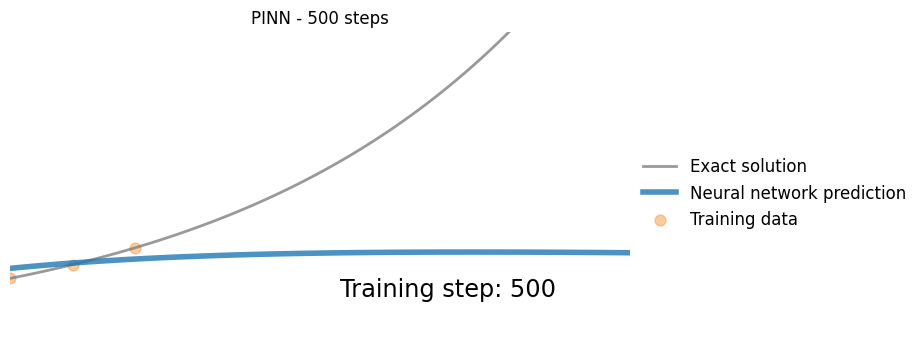

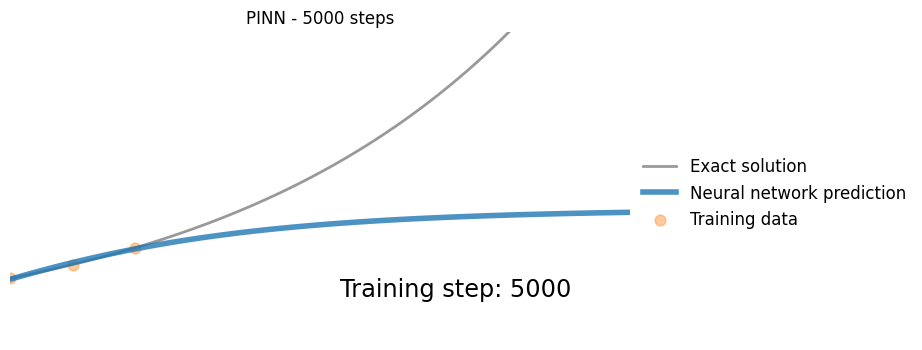

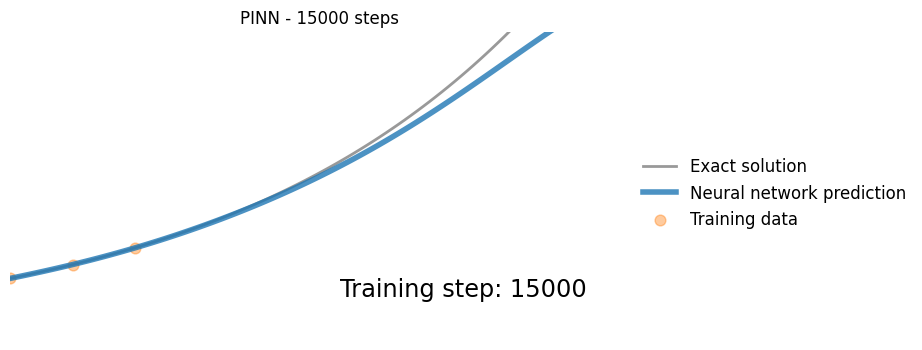

In [ ]:
# ========== Experiment 1: Training Steps - PINN ==========

# --- 500 Iterations ---
torch.manual_seed(123)
model_pinn_500 = FCN(1,1,30,3)
optimizer = torch.optim.Adam(model_pinn_500.parameters(),lr=1e-4)
x_physics = torch.linspace(0,2,30).view(-1,1).requires_grad_(True)
for i in range(500):
    optimizer.zero_grad()
    yh = model_pinn_500(x_data)
    loss1 = torch.mean((yh-y_data)**2)
    yhp = model_pinn_500(x_physics)
    dx = torch.autograd.grad(yhp, x_physics, torch.ones_like(yhp), create_graph=True)[0]
    loss2 = (1e-4)*torch.mean((dx - torch.exp(x_physics))**2)
    loss = loss1 + loss2
    loss.backward()
    optimizer.step()
yh = model_pinn_500(x).detach()
plot_result(x,y,x_data,y_data,yh)
plt.title("PINN - 500 steps")
plt.show()

# --- 5000 Iterations ---
torch.manual_seed(123)
model_pinn_5000 = FCN(1,1,30,3)
optimizer = torch.optim.Adam(model_pinn_5000.parameters(),lr=1e-4)
x_physics = torch.linspace(0,2,30).view(-1,1).requires_grad_(True)
for i in range(5000):
    optimizer.zero_grad()
    yh = model_pinn_5000(x_data)
    loss1 = torch.mean((yh-y_data)**2)
    yhp = model_pinn_5000(x_physics)
    dx = torch.autograd.grad(yhp, x_physics, torch.ones_like(yhp), create_graph=True)[0]
    loss2 = (1e-4)*torch.mean((dx - torch.exp(x_physics))**2)
    loss = loss1 + loss2
    loss.backward()
    optimizer.step()
yh = model_pinn_5000(x).detach()
plot_result(x,y,x_data,y_data,yh)
plt.title("PINN - 5000 steps")
plt.show()

# --- 15000 Iterations ---
torch.manual_seed(123)
model_pinn_15000 = FCN(1,1,30,3)
optimizer = torch.optim.Adam(model_pinn_15000.parameters(),lr=1e-4)
x_physics = torch.linspace(0,2,30).view(-1,1).requires_grad_(True)
for i in range(15000):
    optimizer.zero_grad()
    yh = model_pinn_15000(x_data)
    loss1 = torch.mean((yh-y_data)**2)
    yhp = model_pinn_15000(x_physics)
    dx = torch.autograd.grad(yhp, x_physics, torch.ones_like(yhp), create_graph=True)[0]
    loss2 = (1e-4)*torch.mean((dx - torch.exp(x_physics))**2)
    loss = loss1 + loss2
    loss.backward()
    optimizer.step()
yh = model_pinn_15000(x).detach()
plot_result(x,y,x_data,y_data,yh)
plt.title("PINN - 15000 steps")
plt.show()

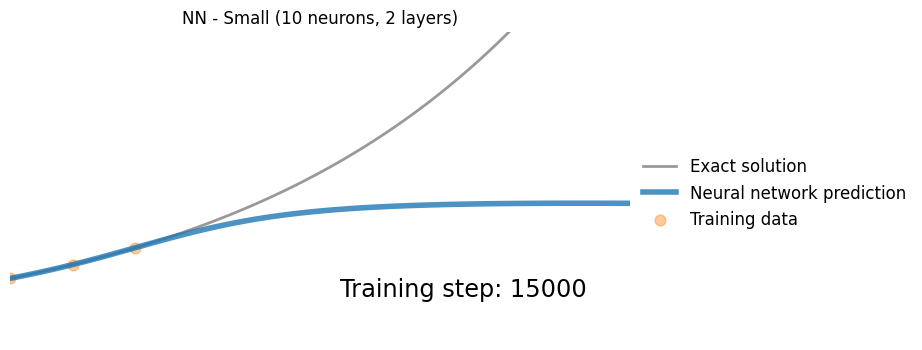

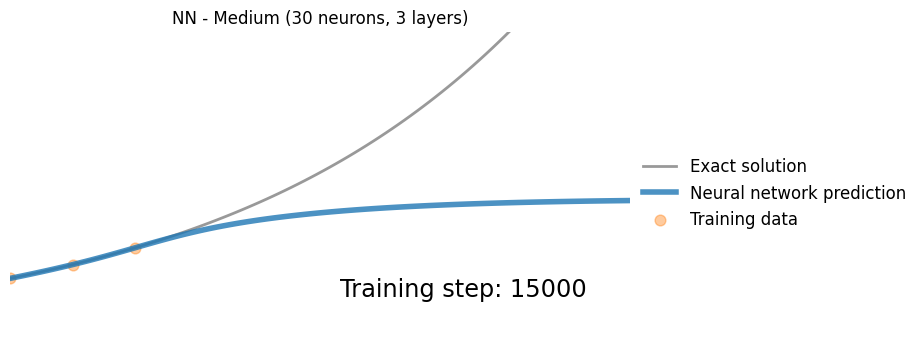

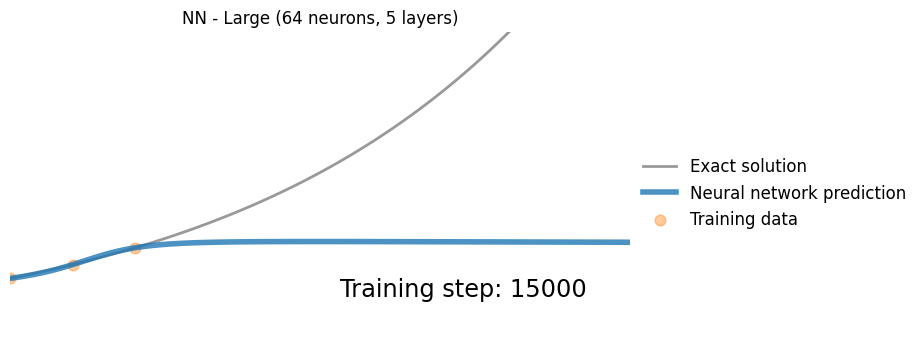

In [ ]:
# ========== Experiment 2: Network Architecture - NN ==========

# --- Small: 10 neurons, 2 layers ---
torch.manual_seed(123)
model_nn_small = FCN(1,1,10,2)
optimizer = torch.optim.Adam(model_nn_small.parameters(),lr=1e-3)
for i in range(15000):
    optimizer.zero_grad()
    yh = model_nn_small(x_data)
    loss = torch.mean((yh-y_data)**2)
    loss.backward()
    optimizer.step()
yh = model_nn_small(x).detach()
plot_result(x,y,x_data,y_data,yh)
plt.title("NN - Small (10 neurons, 2 layers)")
plt.show()

# --- Medium: 30 neurons, 3 layers (original) ---
torch.manual_seed(123)
model_nn_mid = FCN(1,1,30,3)
optimizer = torch.optim.Adam(model_nn_mid.parameters(),lr=1e-3)
for i in range(15000):
    optimizer.zero_grad()
    yh = model_nn_mid(x_data)
    loss = torch.mean((yh-y_data)**2)
    loss.backward()
    optimizer.step()
yh = model_nn_mid(x).detach()
plot_result(x,y,x_data,y_data,yh)
plt.title("NN - Medium (30 neurons, 3 layers)")
plt.show()

# --- Large: 64 neurons, 5 layers ---
torch.manual_seed(123)
model_nn_large = FCN(1,1,64,5)
optimizer = torch.optim.Adam(model_nn_large.parameters(),lr=1e-3)
for i in range(15000):
    optimizer.zero_grad()
    yh = model_nn_large(x_data)
    loss = torch.mean((yh-y_data)**2)
    loss.backward()
    optimizer.step()
yh = model_nn_large(x).detach()
plot_result(x,y,x_data,y_data,yh)
plt.title("NN - Large (64 neurons, 5 layers)")
plt.show()

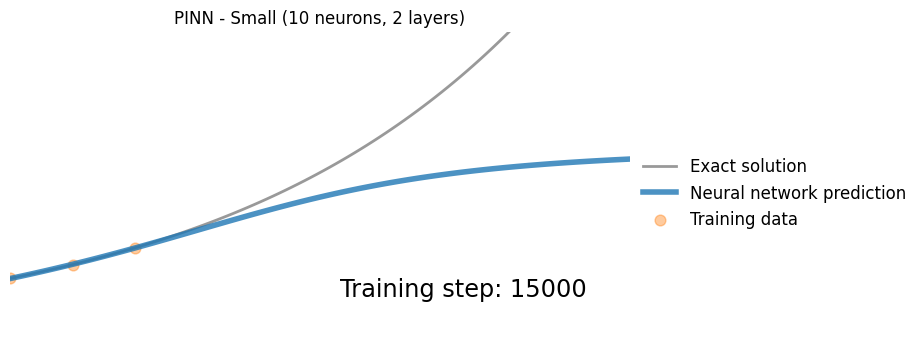

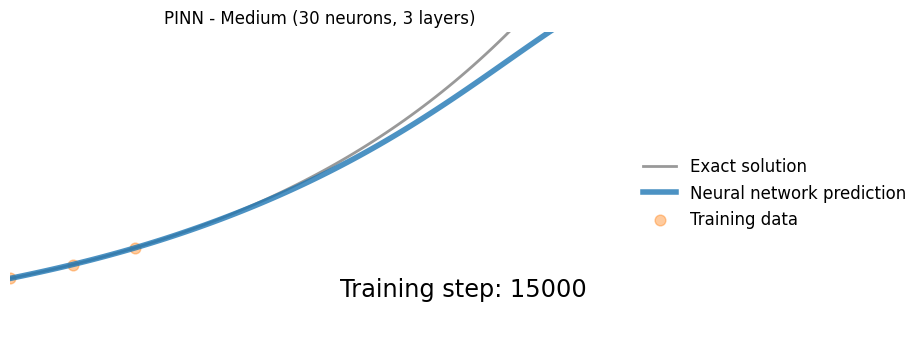

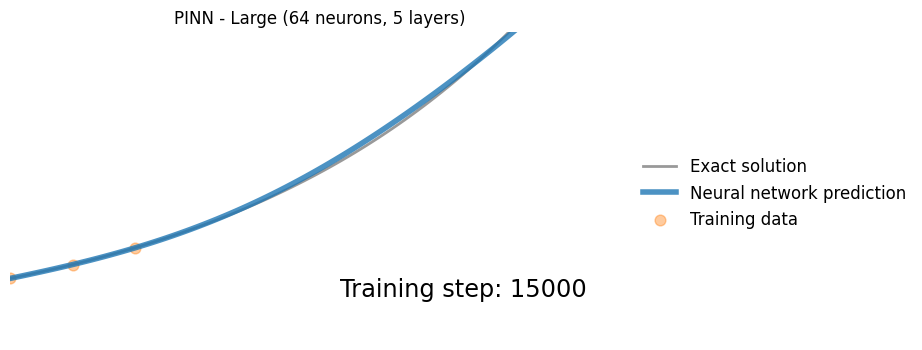

In [ ]:
# ========== Experiment 2: Network Architecture - PINN ==========

# --- Small: 10 neurons, 2 layers ---
torch.manual_seed(123)
model_small = FCN(1,1,10,2)
optimizer = torch.optim.Adam(model_small.parameters(),lr=1e-4)
x_physics = torch.linspace(0,2,30).view(-1,1).requires_grad_(True)
for i in range(15000):
    optimizer.zero_grad()
    yh = model_small(x_data)
    loss1 = torch.mean((yh-y_data)**2)
    yhp = model_small(x_physics)
    dx = torch.autograd.grad(yhp, x_physics, torch.ones_like(yhp), create_graph=True)[0]
    loss2 = (1e-4)*torch.mean((dx - torch.exp(x_physics))**2)
    loss = loss1 + loss2
    loss.backward()
    optimizer.step()
yh = model_small(x).detach()
plot_result(x,y,x_data,y_data,yh)
plt.title("PINN - Small (10 neurons, 2 layers)")
plt.show()

# --- Medium: 30 neurons, 3 layers (original) ---
torch.manual_seed(123)
model_mid = FCN(1,1,30,3)
optimizer = torch.optim.Adam(model_mid.parameters(),lr=1e-4)
x_physics = torch.linspace(0,2,30).view(-1,1).requires_grad_(True)
for i in range(15000):
    optimizer.zero_grad()
    yh = model_mid(x_data)
    loss1 = torch.mean((yh-y_data)**2)
    yhp = model_mid(x_physics)
    dx = torch.autograd.grad(yhp, x_physics, torch.ones_like(yhp), create_graph=True)[0]
    loss2 = (1e-4)*torch.mean((dx - torch.exp(x_physics))**2)
    loss = loss1 + loss2
    loss.backward()
    optimizer.step()
yh = model_mid(x).detach()
plot_result(x,y,x_data,y_data,yh)
plt.title("PINN - Medium (30 neurons, 3 layers)")
plt.show()

# --- Large: 64 neurons, 5 layers ---
torch.manual_seed(123)
model_large = FCN(1,1,64,5)
optimizer = torch.optim.Adam(model_large.parameters(),lr=1e-4)
x_physics = torch.linspace(0,2,30).view(-1,1).requires_grad_(True)
for i in range(15000):
    optimizer.zero_grad()
    yh = model_large(x_data)
    loss1 = torch.mean((yh-y_data)**2)
    yhp = model_large(x_physics)
    dx = torch.autograd.grad(yhp, x_physics, torch.ones_like(yhp), create_graph=True)[0]
    loss2 = (1e-4)*torch.mean((dx - torch.exp(x_physics))**2)
    loss = loss1 + loss2
    loss.backward()
    optimizer.step()
yh = model_large(x).detach()
plot_result(x,y,x_data,y_data,yh)
plt.title("PINN - Large (64 neurons, 5 layers)")
plt.show()

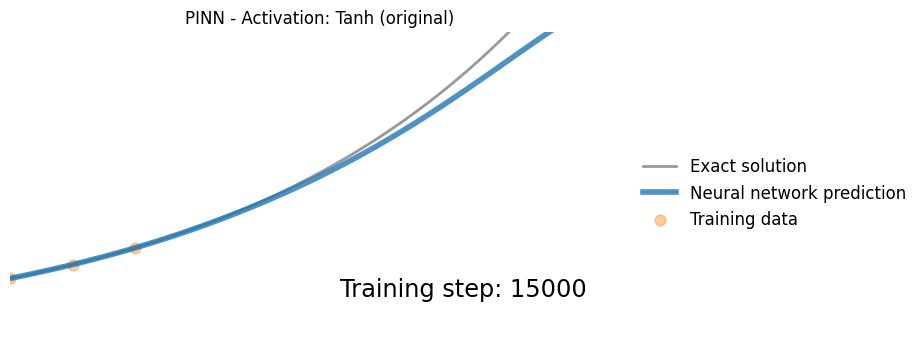

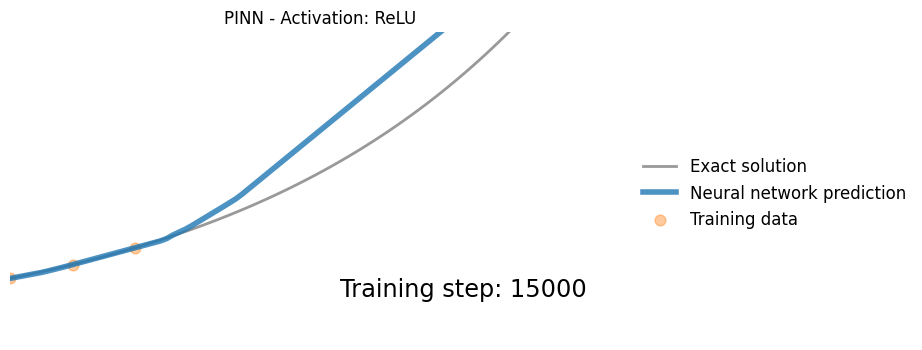

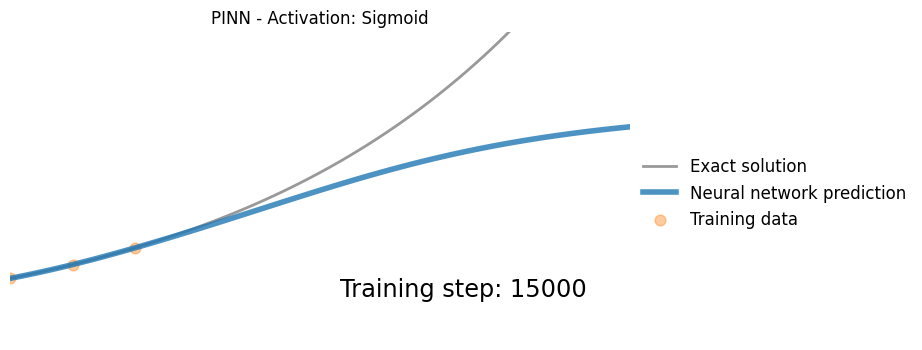

In [ ]:
# ========== Experiment 2 (Additional): Activation Functions - PINN ==========

for act, act_name in [(nn.Tanh, "Tanh (original)"),
                       (nn.ReLU, "ReLU"),
                       (nn.Sigmoid, "Sigmoid")]:

    # redefine FCN with different activation
    class FCN_act(nn.Module):
        def __init__(self, n_input, n_output, n_hidden, n_layers):
            super().__init__()
            activation = act
            self.fcs = nn.Sequential(*[
                            nn.Linear(n_input, n_hidden),
                            activation()])
            self.fch = nn.Sequential(*[
                            nn.Sequential(*[
                                nn.Linear(n_hidden, n_hidden),
                                activation()]) for _ in range(n_layers-1)])
            self.fce = nn.Linear(n_hidden, n_output)
        def forward(self, x):
            x = self.fcs(x)
            x = self.fch(x)
            x = self.fce(x)
            return x

    torch.manual_seed(123)
    m = FCN_act(1,1,30,3)
    opt = torch.optim.Adam(m.parameters(),lr=1e-4)
    x_physics = torch.linspace(0,2,30).view(-1,1).requires_grad_(True)
    for i in range(15000):
        opt.zero_grad()
        yh = m(x_data)
        loss1 = torch.mean((yh-y_data)**2)
        yhp = m(x_physics)
        dx = torch.autograd.grad(yhp, x_physics, torch.ones_like(yhp), create_graph=True)[0]
        loss2 = (1e-4)*torch.mean((dx - torch.exp(x_physics))**2)
        loss = loss1 + loss2
        loss.backward()
        opt.step()
    yh = m(x).detach()
    plot_result(x,y,x_data,y_data,yh)
    plt.title(f"PINN - Activation: {act_name}")
    plt.show()

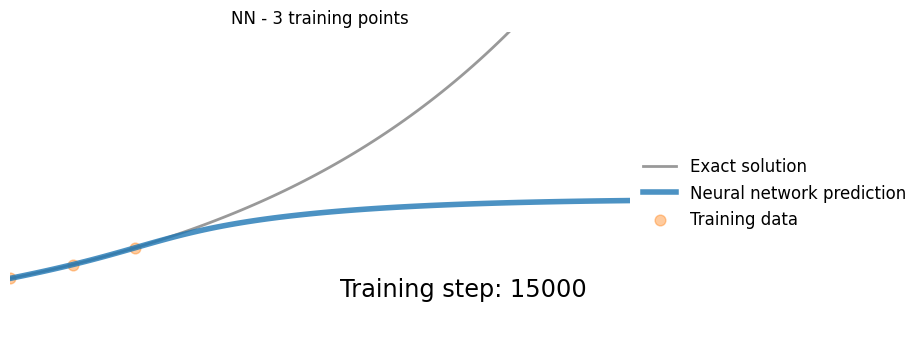

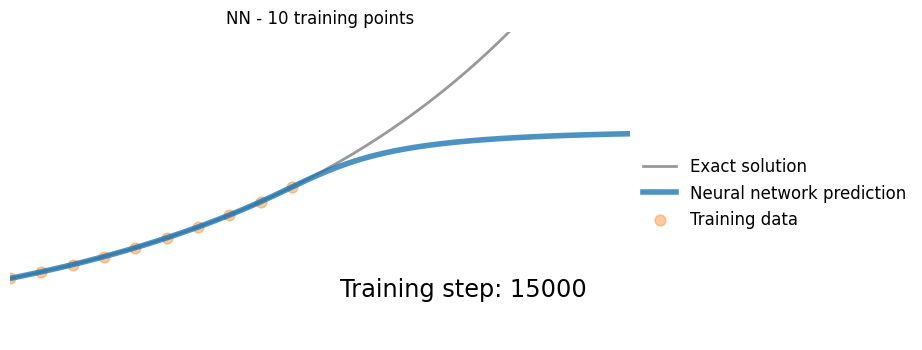

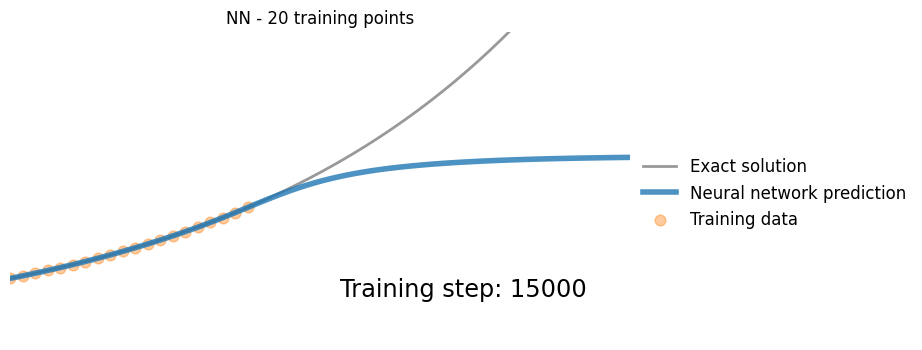

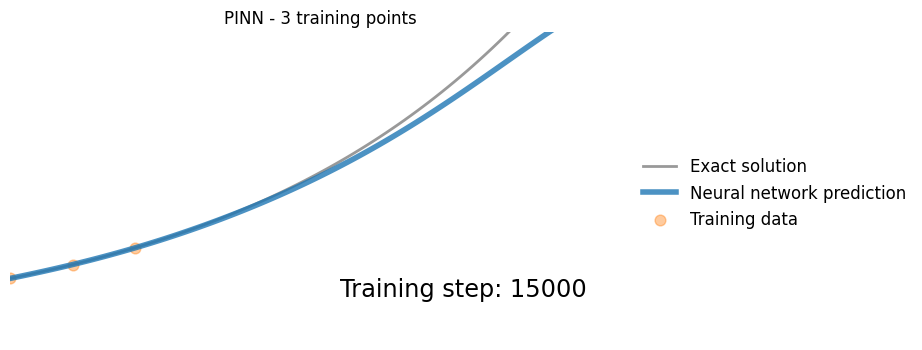

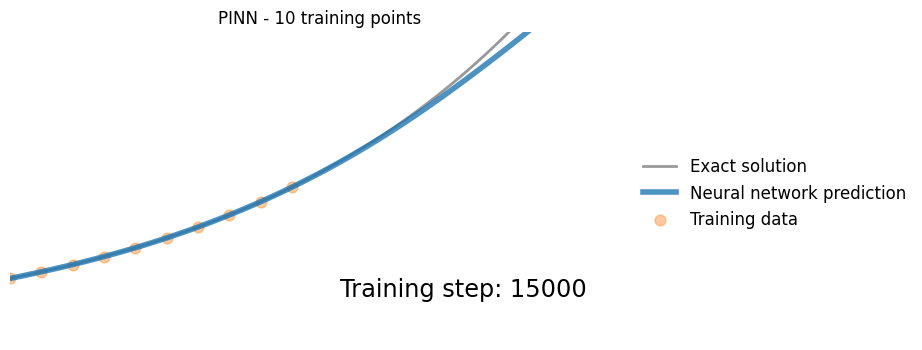

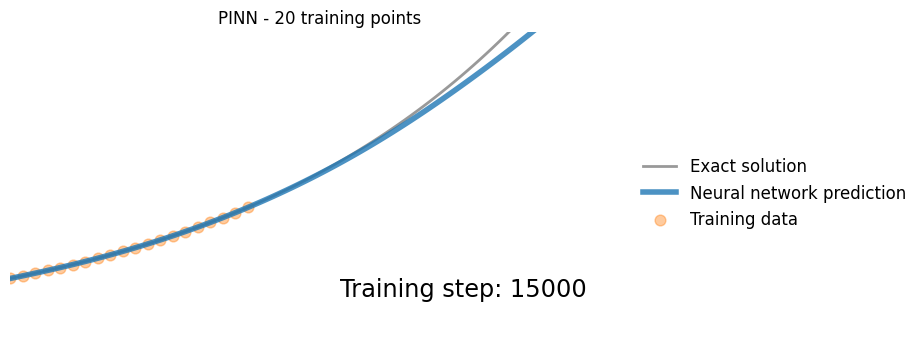

In [ ]:
# ========== Experiment 3: Training Data Size ==========

# --- 3 data points (original) ---
x_data_3 = x[0:30:10]
y_data_3 = y[0:30:10]

# --- 10 data points ---
x_data_10 = x[0:50:5]
y_data_10 = y[0:50:5]

# --- 20 data points ---
x_data_20 = x[0:40:2]
y_data_20 = y[0:40:2]

# == NN ==
for x_d, y_d, n in [(x_data_3, y_data_3, 3),
                     (x_data_10, y_data_10, 10),
                     (x_data_20, y_data_20, 20)]:
    torch.manual_seed(123)
    m = FCN(1,1,30,3)
    opt = torch.optim.Adam(m.parameters(),lr=1e-3)
    for i in range(15000):
        opt.zero_grad()
        yh = m(x_d)
        loss = torch.mean((yh-y_d)**2)
        loss.backward()
        opt.step()
    yh = m(x).detach()
    plot_result(x,y,x_d,y_d,yh)
    plt.title(f"NN - {n} training points")
    plt.show()

# == PINN ==
x_physics = torch.linspace(0,2,30).view(-1,1).requires_grad_(True)
for x_d, y_d, n in [(x_data_3, y_data_3, 3),
                     (x_data_10, y_data_10, 10),
                     (x_data_20, y_data_20, 20)]:
    torch.manual_seed(123)
    m = FCN(1,1,30,3)
    opt = torch.optim.Adam(m.parameters(),lr=1e-4)
    for i in range(15000):
        opt.zero_grad()
        yh = m(x_d)
        loss1 = torch.mean((yh-y_d)**2)
        yhp = m(x_physics)
        dx = torch.autograd.grad(yhp, x_physics, torch.ones_like(yhp), create_graph=True)[0]
        loss2 = (1e-4)*torch.mean((dx - torch.exp(x_physics))**2)
        loss = loss1 + loss2
        loss.backward()
        opt.step()
    yh = m(x).detach()
    plot_result(x,y,x_d,y_d,yh)
    plt.title(f"PINN - {n} training points")
    plt.show()

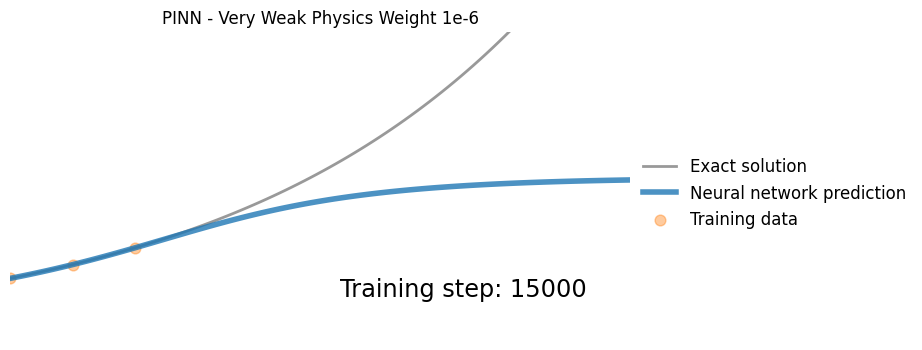

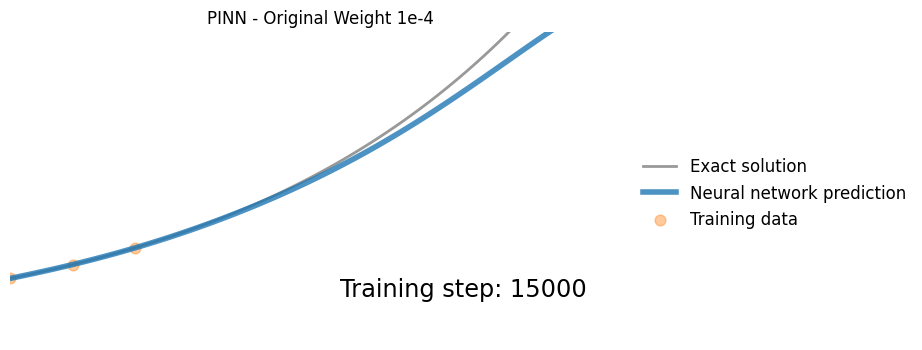

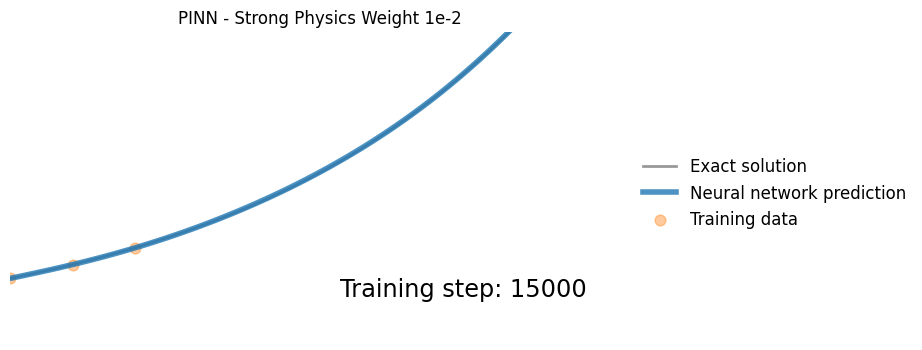

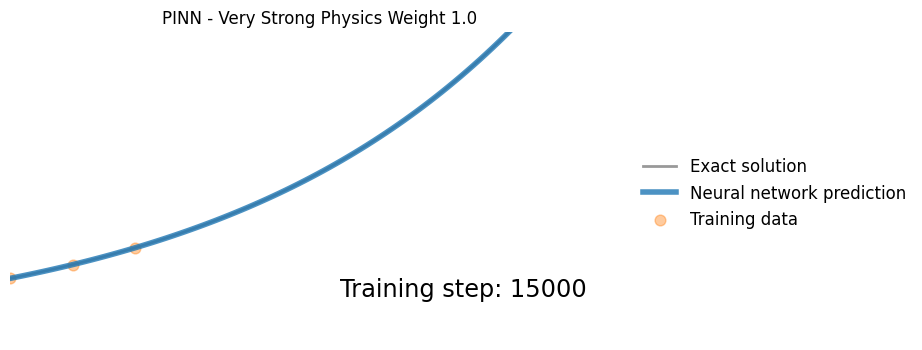

In [ ]:
# ========== Experiment 4: Physics Loss Weight ==========

x_physics = torch.linspace(0,2,30).view(-1,1).requires_grad_(True)

for weight, label in [(1e-6, "Very Weak Physics Weight 1e-6"),
                      (1e-4, "Original Weight 1e-4"),
                      (1e-2, "Strong Physics Weight 1e-2"),
                      (1.0,  "Very Strong Physics Weight 1.0")]:
    torch.manual_seed(123)
    m = FCN(1,1,30,3)
    opt = torch.optim.Adam(m.parameters(),lr=1e-4)
    for i in range(15000):
        opt.zero_grad()
        yh = m(x_data)
        loss1 = torch.mean((yh-y_data)**2)
        yhp = m(x_physics)
        dx = torch.autograd.grad(yhp, x_physics, torch.ones_like(yhp), create_graph=True)[0]
        loss2 = weight*torch.mean((dx - torch.exp(x_physics))**2)
        loss = loss1 + loss2
        loss.backward()
        opt.step()
    yh = m(x).detach()
    plot_result(x,y,x_data,y_data,yh)
    plt.title(f"PINN - {label}")
    plt.show()

References:

[1]. Guo, W. (2024). Physics Informed Machine Learning for Predicting the Degradation Behavior of Lithium-ion Batteries. https://doi.org/10.54337/aau755548824

[2]. Karniadakis, George Em, et al. "Physics-informed machine learning." Nature Reviews Physics 3.6 (2021): 422-440.